**PHASE 1: Clinical Processing**


In [ ]:
!pip install spacy wordcloud scikit-learn pandas matplotlib
!python -m spacy download en_core_web_sm #spacy - Module use to implement NLP pipeline (Segmentation, Tokenization, Lemmatization, POS tagging, NER, Dependency Parsing )
                                         # en_core_web - NLP pipeline for english

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 82.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving mtsamples.csv to mtsamples.csv


In [ ]:
import pandas as pd
import re
import spacy
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from spacy import displacy
import warnings
warnings.filterwarnings('ignore')

nlp = spacy.load("en_core_web_sm")
print("All libraries loaded!")

All libraries loaded!


In [ ]:
# Load the dataset
df = pd.read_csv('mtsamples.csv')

# Preview the data
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(5)

Shape: (4999, 6)

Columns: ['Unnamed: 0', 'description', 'medical_specialty', 'sample_name', 'transcription', 'keywords']


,Unnamed: 0,description,medical_specialty,sample_name,transcription,keywords
0,0,A 23-year-old white female presents with comp...,Allergy / Immunology,Allergic Rhinitis,"SUBJECTIVE:, This 23-year-old white female pr...","allergy / immunology, allergic rhinitis, aller..."
1,1,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 2,"PAST MEDICAL HISTORY:, He has difficulty climb...","bariatrics, laparoscopic gastric bypass, weigh..."
2,2,Consult for laparoscopic gastric bypass.,Bariatrics,Laparoscopic Gastric Bypass Consult - 1,"HISTORY OF PRESENT ILLNESS: , I have seen ABC ...","bariatrics, laparoscopic gastric bypass, heart..."
3,3,2-D M-Mode. Doppler.,Cardiovascular / Pulmonary,2-D Echocardiogram - 1,"2-D M-MODE: , ,1. Left atrial enlargement wit...","cardiovascular / pulmonary, 2-d m-mode, dopple..."
4,4,2-D Echocardiogram,Cardiovascular / Pulmonary,2-D Echocardiogram - 2,1. The left ventricular cavity size and wall ...,"cardiovascular / pulmonary, 2-d, doppler, echo..."


In [ ]:
# Check specialty counts to select top 4
print(df['medical_specialty'].value_counts().head(10))

medical_specialty
Surgery                          1103
Consult - History and Phy.        516
Cardiovascular / Pulmonary        372
Orthopedic                        355
Radiology                         273
General Medicine                  259
Gastroenterology                  230
Neurology                         223
SOAP / Chart / Progress Notes     166
Obstetrics / Gynecology           160
Name: count, dtype: int64


In [ ]:
# Filter to top 4 specialties
selected = [
    ' Surgery',
    ' Consult - History and Phy.',
    ' Cardiovascular / Pulmonary',
    ' Orthopedic'
]

df_filtered = df[df['medical_specialty'].isin(selected)].copy()
df_filtered = df_filtered[['medical_specialty', 'transcription']].dropna()

# Strip whitespace just in case
df_filtered['medical_specialty'] = df_filtered['medical_specialty'].str.strip()

print(f"Total records: {len(df_filtered)}")
print(df_filtered['medical_specialty'].value_counts())

Total records: 2330
medical_specialty
Surgery                       1088
Consult - History and Phy.     516
Cardiovascular / Pulmonary     371
Orthopedic                     355
Name: count, dtype: int64


In [ ]:
import re
import spacy

nlp = spacy.load("en_core_web_sm")

In [ ]:
NEGATION_TERMS = {
    'no',
    'not',
    'without',
    'denies',
    'denied',
    'negative'
}

In [ ]:
MEDICAL_ABBREVIATIONS = {

    # ---- Imaging / Echo ----
    r'\b2\s*-?\s*d\b':        'two dimensional',
    r'\bm\s*-?\s*mode\b':    'motion mode',
    r'\bdoppler\b':          'doppler',

    # ---- Chambers / Cardiology ----
    r'\blv\b':               'left ventricle',
    r'\brv\b':               'right ventricle',
    r'\bef\b':               'ejection fraction',
    r'\bpa\b':               'pulmonary artery',

    # ---- General / H&P ----
    r'\bpt\b':               'patient',
    r'\bh&p\b':              'history and physical',
    r'\bh\+p\b':             'history and physical',
    r'\bhx\b':               'history',
    r'\bhpi\b':              'history of present illness',
    r'\bpmh\b':              'past medical history',
    r'\bfh\b':               'family history',
    r'\bsh\b':               'social history',
    r'\bcc\b':               'chief complaint',
    r'\bc/o\b':              'complains of',
    r'\bcons\b':             'consultation',
    r'\by/o\b':              'year old',
    r'\byo\b':               'year old',
    r'\bwf\b':               'white female',

    # ---- Vitals ----
    r'\bvs\b':               'vital signs',
    r'\bbp\b':               'blood pressure',
    r'\bhr\b':               'heart rate',
    r'\brr\b':               'respiratory rate',
    r'\bpr\b':               'pulse rate',
    r'\bo2\s*sat\b':         'oxygen saturation',

    # ---- Diseases ----
    r'\bmi\b':               'myocardial infarction',
    r'\bhtn\b':              'hypertension',
    r'\bdm\b':               'diabetes mellitus',
    r'\bsob\b':              'shortness of breath',
    r'\bcad\b':              'coronary artery disease',
    r'\bchf\b':              'congestive heart failure',
    r'\bcopd\b':             'chronic obstructive pulmonary disease',

    # ---- Ortho ----
    r'\borif\b':             'open reduction internal fixation',
    r'\boa\b':               'osteoarthritis',
    r'\bacl\b':              'anterior cruciate ligament',
    r'\brom\b':              'range of motion',
    r'\bthr\b':              'total hip replacement',
    r'\btha\b':              'total hip arthroplasty',
    r'\btkr\b':              'total knee replacement',
    r'\btka\b':              'total knee arthroplasty',

    # ---- Gyn Surgery ----
    r'\btah\b':              'total abdominal hysterectomy',
    r'\btahbso\b':           'total abdominal hysterectomy and bilateral salpingo oophorectomy',

    # ---- Labs ----
    r'\bwbc\b':              'white blood cell',
    r'\brbc\b':              'red blood cell',
    r'\bcva\b':              'cerebrovascular accident',
    r'\buri\b':              'upper respiratory infection',
}

In [ ]:
def remove_noise(text):

    # Remove metadata headers
    text = re.sub(
        r'^(sample name|description|medical specialty|keywords|patient id|'
        r'patient name|date of birth|age|gender|referring physician|'
        r'admitting diagnosis|date of admission|date of discharge|'
        r'date of procedure)\s*:.*$',
        '',
        text,
        flags=re.IGNORECASE | re.MULTILINE
    )

    # Remove ALL-CAPS section headers only (Example - LAB RESULTS: ; PAST MEDICAL HISTORY:)
    text = re.sub(
        r'^[A-Z][A-Z\s]{2,}:\s*$',
        '',
        text,
        flags=re.MULTILINE
    )

    # Remove dictation artifacts
    text = re.sub(
        r'(dictated by|dictated on|transcribed by|electronically signed by|'
        r'this concludes the dictation|thank you for (allowing|the referral)).*',
        '',
        text,
        flags=re.IGNORECASE
    )

    # Remove PHI placeholders
    text = re.sub(r'\[\*\*.*?\*\*\]', '', text) #Removes: [**Name**] [**Hospital ID**] [**Date**] etc..
    text = re.sub(r'[_X]{3,}', '', text)        #Removes: underscores and 'xx' markings

    text = re.sub(r'\b\d+\.(?=\s)', '', text)   #Removes numbered bullets

    # Normalize whitespace
    text = re.sub(r'\n+', ' ', text)
    text = re.sub(r'\s{2,}', ' ', text)

    # Keep units %, numbers, punctuation
    text = re.sub(r'[^a-zA-Z0-9\s.,%]', '', text)

    return text.strip()

In [ ]:
def expand_abbreviations(text): #Expand all abbrevations
    text = text.lower()
    for abbr, full in MEDICAL_ABBREVIATIONS.items():
        text = re.sub(abbr, full, text, flags=re.IGNORECASE)
    return text

In [ ]:
def protect_laterality(text):
    text = re.sub(r'\bleft\b', 'left_side', text, flags=re.IGNORECASE)            #on Lemmatization left is replace by base word leave - so preserve laterality
    text = re.sub(r'\bright\b', 'right_side', text, flags=re.IGNORECASE)
    return text

In [ ]:
def lemmatize_text(text):
    doc = nlp(text)
    tokens = [
        token.lemma_
        for token in doc
        if (
            (not token.is_stop or token.text.lower() in NEGATION_TERMS)
            and not token.is_punct
            and (
                len(token.text) > 2
                or token.text.lower() in NEGATION_TERMS
                or token.text.isdigit()
                or token.text.lower() in {'ef', 'lv', 'rv'}
            )
        )
    ]
    return ' '.join(tokens)

    # Token inclusion rules:
# - Lemmatize each token (use base form of the word)
# - Remove stopwords EXCEPT negation terms defined above
# - Exclude punctuation tokens (!,.])
# - Keep tokens that meet ANY of the following:
#     • Token length ≥ 2 characters
#     • Token is a negation term (even if short)
#     • Token is a number (preserves vitals, labs, measurements)
#     • Token is a key clinical abbreviation (e.g., EF, LV, RV)

In [ ]:
def restore_laterality(text):
    return text.replace('left_side', 'left').replace('right_side', 'right')

In [ ]:
def preprocess(text):
    text = remove_noise(text)
    text = expand_abbreviations(text)
    text = protect_laterality(text)
    text = lemmatize_text(text)
    text = restore_laterality(text)
    return text

In [ ]:
# Apply preprocessing steps to all transcriptions
print("Preprocessing all transcriptions...")
df_filtered['clean_text'] = df_filtered['transcription'].apply(preprocess)
print("Done.")

Preprocessing all transcriptions...
Done.


In [ ]:
idx = df_filtered.index[0]

print("\n--- ORIGINAL  ---")
print(df_filtered.loc[idx, 'transcription'][:10000])

print("\n--- CLEANED ---")
print(df_filtered.loc[idx, 'clean_text'][:10000])


--- ORIGINAL  ---
2-D M-MODE: , ,1.  Left atrial enlargement with left atrial diameter of 4.7 cm.,2.  Normal size right and left ventricle.,3.  Normal LV systolic function with left ventricular ejection fraction of 51%.,4.  Normal LV diastolic function.,5.  No pericardial effusion.,6.  Normal morphology of aortic valve, mitral valve, tricuspid valve, and pulmonary valve.,7.  PA systolic pressure is 36 mmHg.,DOPPLER: , ,1.  Mild mitral and tricuspid regurgitation.,2.  Trace aortic and pulmonary regurgitation.

--- CLEANED ---
dimensional motion mode left atrial enlargement left atrial diameter 4.7 normal size right left ventricle normal left ventricle systolic function left ventricular ejection fraction 51 normal left ventricle diastolic function no pericardial effusion normal morphology aortic valve mitral valve tricuspid valve pulmonary valve pulmonary artery systolic pressure 36 mmhg ,doppler mild mitral tricuspid regurgitation trace aortic pulmonary regurgitation


**PHASE 2: Entity Extraction via POS Tagging**

In [ ]:
def extract_medical_entities(text, pos_tags=('NN', 'NNS', 'JJ')):

    doc = nlp(text)
    entities = [
        token.lemma_
        for token in doc
        if token.tag_ in pos_tags
        and not token.is_stop
        and not token.is_punct
        and (
            len(token.text) > 2
            or token.text.lower() in {'lv', 'rv', 'ef', 'pa'}
        )
    ]
    return entities

In [ ]:
cardiology_text = ' '.join(
    df_filtered[
        df_filtered['medical_specialty'] == 'Cardiovascular / Pulmonary'
    ]['clean_text']
)

orthopedic_text = ' '.join(
    df_filtered[
        df_filtered['medical_specialty'] == 'Orthopedic'
    ]['clean_text']
)

In [ ]:
cardiology_entities = extract_medical_entities(cardiology_text)
orthopedic_entities = extract_medical_entities(orthopedic_text)

In [ ]:
!pip install wordcloud

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

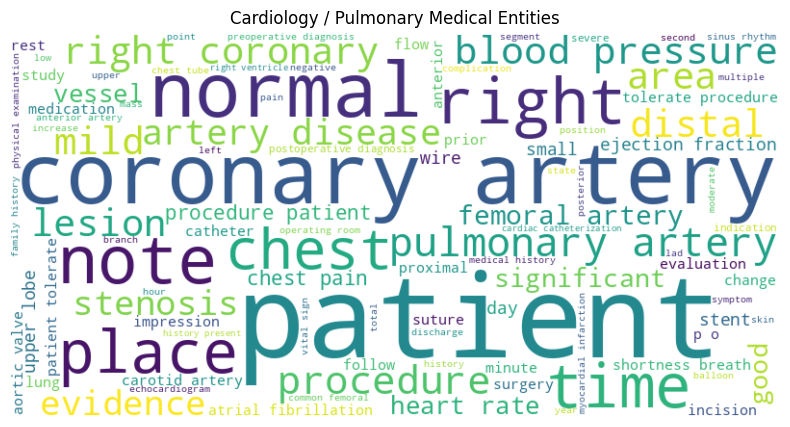

In [ ]:
cardio_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(' '.join(cardiology_entities))

plt.figure(figsize=(10, 5))
plt.imshow(cardio_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Cardiology / Pulmonary Medical Entities')
plt.show()

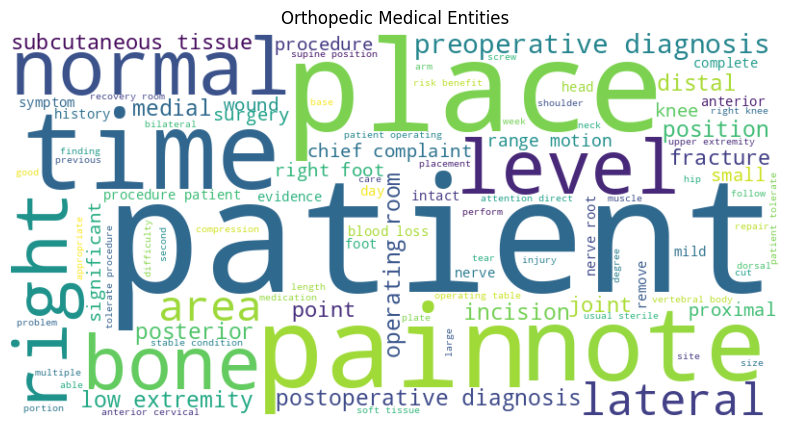

In [ ]:
ortho_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100
).generate(' '.join(orthopedic_entities))

plt.figure(figsize=(10, 5))
plt.imshow(ortho_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Orthopedic Medical Entities')
plt.show()

**Phase 3: Syntax & Negation Analysis**
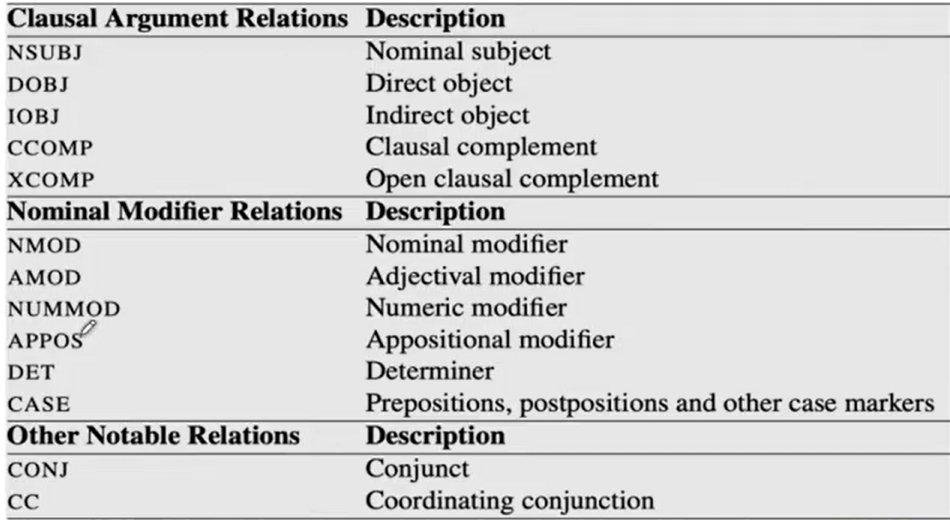

In [ ]:
NEGATION_TERMS = {
    'no',
    'not',
    'without',
    'denies',
    'denied',
    'negative'
}

In [ ]:
def preprocess_for_phase3(text):
    text = remove_noise(text)
    text = expand_abbreviations(text)
    return text.lower()

In [ ]:
def analyze_negation(text, target_entities):
    """
    Determines whether target medical entities are PRESENT or NEGATED
    using dependency parsing.
    """

    doc = nlp(text)
    results = []

    for entity in target_entities:
        entity = entity.lower()

        for token in doc:
            if token.text.lower() == entity:

                negated = False

                # Check children (e.g., "no pain")
                for child in token.children:
                    if child.text.lower() in NEGATION_TERMS:
                        negated = True

                # Check ancestors (e.g., "denies pain")
                for ancestor in token.ancestors:
                    if ancestor.text.lower() in NEGATION_TERMS:
                        negated = True

                results.append({
                    "Entity": entity,
                    "Status": "Negated" if negated else "Present"
                })

    return results

In [ ]:
from spacy import displacy

text = "Patient denies chest pain. No fever. Mild shortness of breath."
doc = nlp(preprocess_for_phase3(text))

displacy.render(doc, style="dep", jupyter=True)

In [ ]:
sample_text = "Patient denies chest pain. No fever. Mild shortness of breath."

entities = ['pain', 'fever', 'breath']

clean_text = preprocess_for_phase3(sample_text)

analyze_negation(clean_text, entities)

[{'Entity': 'pain', 'Status': 'Negated'},
 {'Entity': 'fever', 'Status': 'Negated'},
 {'Entity': 'breath', 'Status': 'Present'}]

**Phase 4: Specialty Classification**  

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
X = df_filtered['clean_text']
y = df_filtered['medical_specialty']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y #
)

In [ ]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced'
)

model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.6781


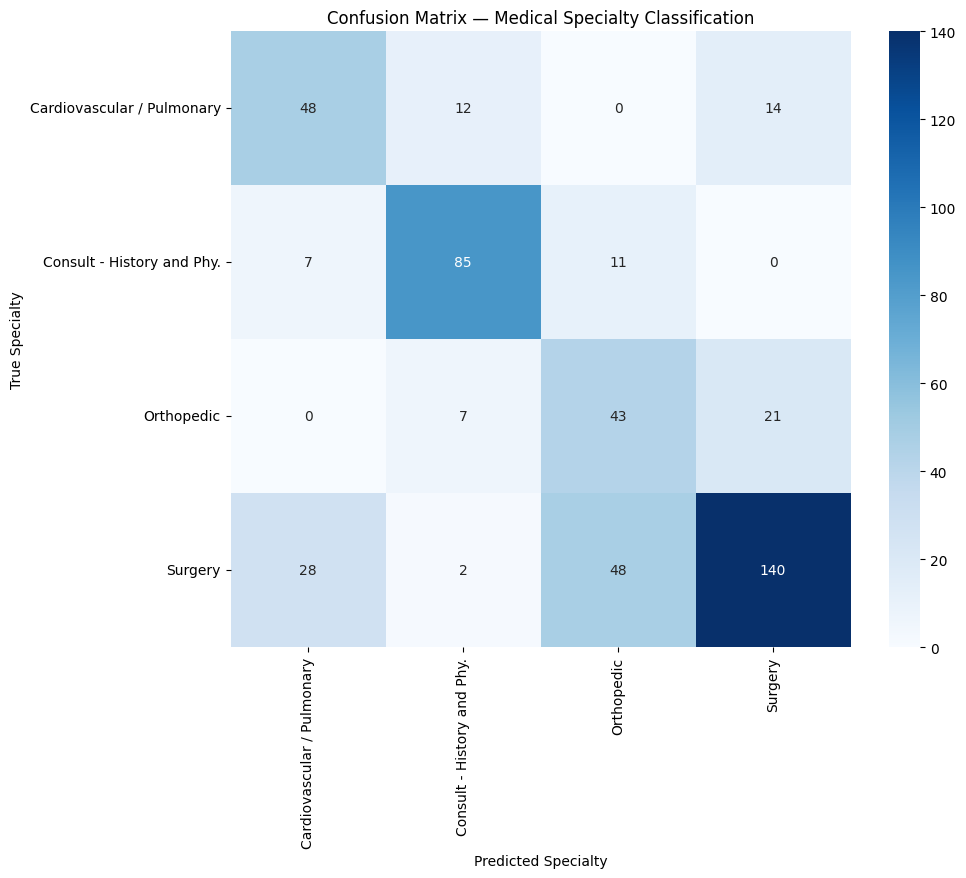

In [ ]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=model.classes_,
    yticklabels=model.classes_,
    cmap='Blues'
)
plt.xlabel("Predicted Specialty")
plt.ylabel("True Specialty")
plt.title("Confusion Matrix — Medical Specialty Classification")
plt.show()

In [ ]:
print(classification_report(y_test, y_pred))

                            precision    recall  f1-score   support

Cardiovascular / Pulmonary       0.58      0.65      0.61        74
Consult - History and Phy.       0.80      0.83      0.81       103
                Orthopedic       0.42      0.61      0.50        71
                   Surgery       0.80      0.64      0.71       218

                  accuracy                           0.68       466
                 macro avg       0.65      0.68      0.66       466
              weighted avg       0.71      0.68      0.69       466



In [ ]:
# ─── MODEL INTERPRETABILITY: TOP FEATURES PER SPECIALTY ───

feature_names = tfidf.get_feature_names_out()

print("=" * 70)
print("TOP 10 WORDS THE MODEL USES TO IDENTIFY EACH SPECIALTY")
print("=" * 70)

for i, specialty in enumerate(model.classes_):
    # Logistic Regression coef_: (n_classes, n_features)
    top_indices = model.coef_[i].argsort()[-10:][::-1]
    top_words = [feature_names[j] for j in top_indices]

    print(f"\n{specialty}:")
    print("  " + ", ".join(top_words))

TOP 10 WORDS THE MODEL USES TO IDENTIFY EACH SPECIALTY

Cardiovascular / Pulmonary:
  chest, pulmonary, lung, lobe, heart, artery, vein, atrial, coronary, pleural

Consult - History and Phy.:
  history, no, not, negative, weight, past, medical, normal, food, present

Orthopedic:
  pain, fracture, knee, tendon, cervical, joint, hip, disc, screw, spine

Surgery:
  procedure, place, diagnosis, remove, bladder, suture, stomach, scope, biopsy, incision


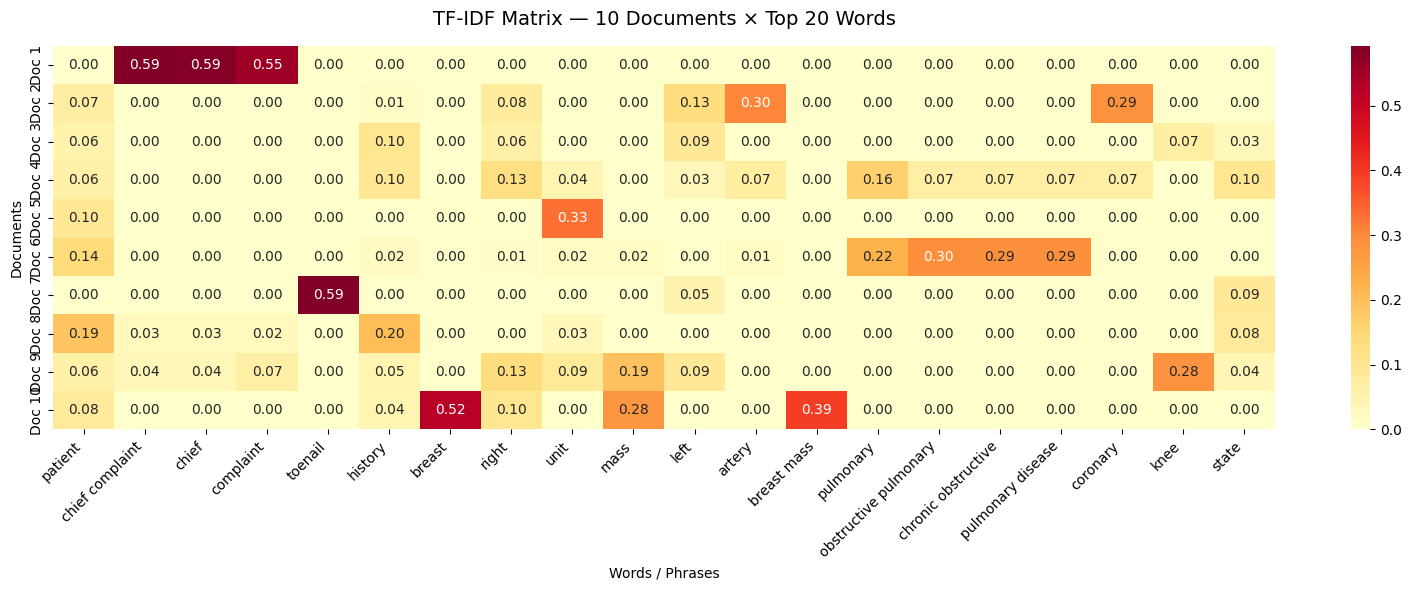

In [ ]:
import seaborn as sns

# Take a small sample — 10 documents and top 20 words
# (full matrix is too large to display meaningfully)
sample_docs = X_train[:10]
sample_tfidf = tfidf.transform(sample_docs)

# Get top 20 feature names by overall score
feature_names = tfidf.get_feature_names_out()
top20_indices = sample_tfidf.toarray().sum(axis=0).argsort()[-20:][::-1]
top20_words = feature_names[top20_indices]
top20_matrix = sample_tfidf.toarray()[:, top20_indices]

# Plot
plt.figure(figsize=(16, 6))
sns.heatmap(
    top20_matrix,
    xticklabels=top20_words,
    yticklabels=[f"Doc {i+1}" for i in range(10)],
    cmap='YlOrRd',
    annot=True,
    fmt='.2f'
)
plt.title('TF-IDF Matrix — 10 Documents × Top 20 Words', fontsize=14, pad=15)
plt.xlabel('Words / Phrases')
plt.ylabel('Documents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('tfidf_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# For each specialty, find which words have the highest average TF-IDF score
# This shows what words DEFINE each specialty according to TF-IDF

print("=" * 65)
print("TOP 10 TF-IDF WORDS PER SPECIALTY")
print("=" * 65)

feature_names = tfidf.get_feature_names_out()

for specialty in df_filtered['medical_specialty'].unique():
    # Get all training documents belonging to this specialty
    mask = y_train == specialty
    specialty_matrix = X_train_tfidf[mask.values]

    # Average TF-IDF score across all documents in this specialty
    avg_scores = specialty_matrix.mean(axis=0).A1

    # Get top 10 indices
    top10_indices = avg_scores.argsort()[-10:][::-1]
    top10_words = [feature_names[i] for i in top10_indices]

    print(f"\n{specialty}:")
    print(f"  {', '.join(top10_words)}")

print("\n" + "=" * 65)

TOP 10 TF-IDF WORDS PER SPECIALTY

Cardiovascular / Pulmonary:
  artery, left, patient, coronary, no, right, chest, pulmonary, normal, history

Surgery:
  patient, procedure, place, right, left, diagnosis, suture, incision, remove, anesthesia

Orthopedic:
  patient, right, pain, place, knee, left, fracture, no, screw, joint

Consult - History and Phy.:
  no, history, patient, not, normal, pain, deny, past, day, negative



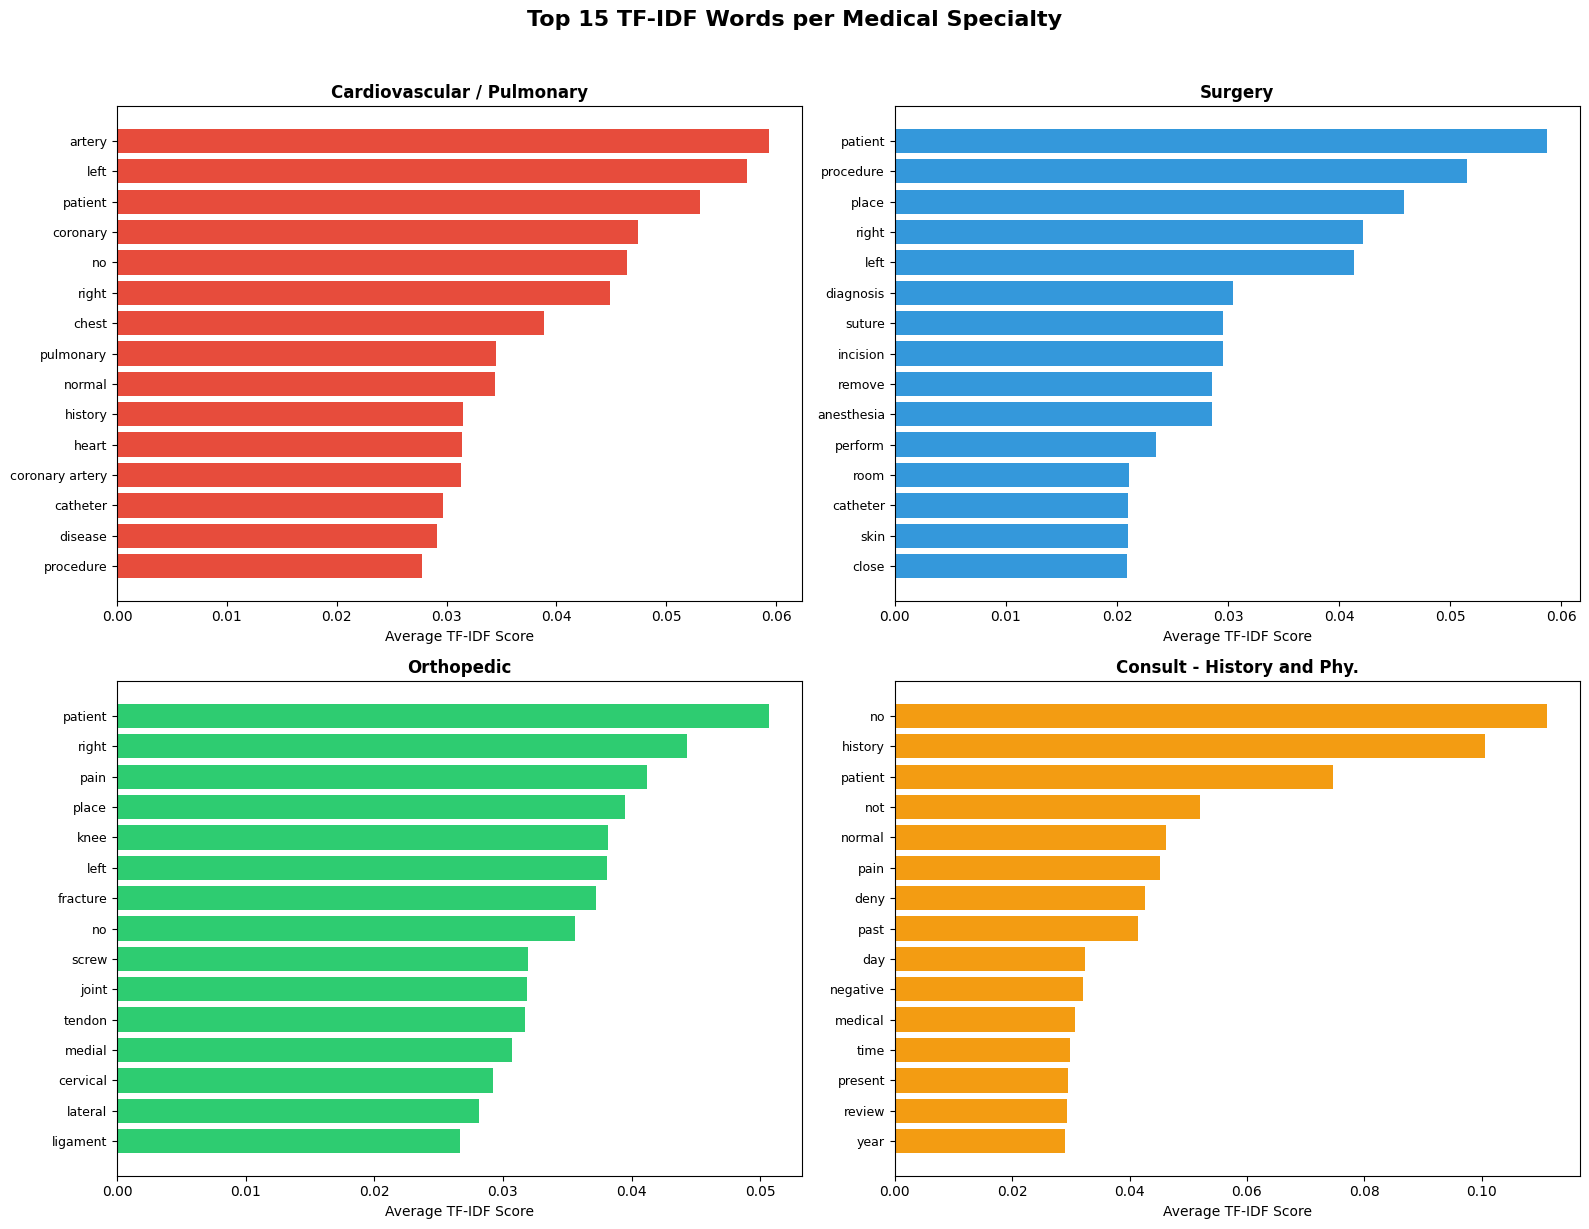

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

feature_names = tfidf.get_feature_names_out()

for idx, specialty in enumerate(df_filtered['medical_specialty'].unique()):
    mask = y_train == specialty
    specialty_matrix = X_train_tfidf[mask.values]
    avg_scores = specialty_matrix.mean(axis=0).A1

    top15_indices = avg_scores.argsort()[-15:][::-1]
    top15_words   = [feature_names[i] for i in top15_indices]
    top15_scores  = [avg_scores[i] for i in top15_indices]

    axes[idx].barh(
        top15_words[::-1],
        top15_scores[::-1],
        color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'][idx]
    )
    axes[idx].set_title(f'{specialty}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Average TF-IDF Score')
    axes[idx].tick_params(axis='y', labelsize=9)

plt.suptitle('Top 15 TF-IDF Words per Medical Specialty',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('tfidf_per_specialty.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Understand the structure of the matrix numerically
import numpy as np

total_cells   = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]
nonzero_cells = X_train_tfidf.nnz
sparsity      = 1 - (nonzero_cells / total_cells)

print("TF-IDF MATRIX SUMMARY")
print("=" * 40)
print(f"Documents (rows)   : {X_train_tfidf.shape[0]}")
print(f"Features (columns) : {X_train_tfidf.shape[1]}")
print(f"Total cells        : {total_cells:,}")
print(f"Non-zero cells     : {nonzero_cells:,}")
print(f"Zero cells         : {total_cells - nonzero_cells:,}")
print(f"Sparsity           : {sparsity*100:.1f}%")
print(f"\nThis means {sparsity*100:.1f}% of the matrix is zeros")
print(f"because most words don't appear in most documents")

TF-IDF MATRIX SUMMARY
Documents (rows)   : 1864
Features (columns) : 5000
Total cells        : 9,320,000
Non-zero cells     : 360,426
Zero cells         : 8,959,574
Sparsity           : 96.1%

This means 96.1% of the matrix is zeros
because most words don't appear in most documents


In [ ]:
import joblib
import os

# Create a folder to store model files
os.makedirs('model', exist_ok=True)

# Save the trained classifier
joblib.dump(model, 'model/classifier.pkl')

# Save the TF-IDF vectorizer
# This is equally important — the vectorizer learned the vocabulary
# If you don't save it, you can't transform new text the same way
joblib.dump(tfidf, 'model/vectorizer.pkl')

print("Model saved   : model/classifier.pkl")
print("Vectorizer saved : model/vectorizer.pkl")
print(f"\nModel file size     : {os.path.getsize('model/classifier.pkl') / 1024:.1f} KB")
print(f"Vectorizer file size: {os.path.getsize('model/vectorizer.pkl') / 1024:.1f} KB")

Model saved   : model/classifier.pkl
Vectorizer saved : model/vectorizer.pkl

Model file size     : 157.3 KB
Vectorizer file size: 195.0 KB


In [ ]:
from google.colab import files

# Download both files
files.download('model/classifier.pkl')
files.download('model/vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>